# TetheredAI MLB Modeling Lab — Batted-Ball Features, Correlations, Interactions, and Scoring-Candidate Filtering

This notebook is designed for your upgraded feature file after adding team batted-ball velocity and batted-ball distance features upstream.

It covers:

- Exact date range and target counts
- Correct separation of completed/labeled, unresolved, and true upcoming scoring-candidate rows
- Batted-ball feature availability checks
- Missingness rules and missing indicators
- Correlation-to-target and feature-redundancy analysis
- Baseball-logical interaction terms
- Chronological model comparison
- Calibration diagnostics
- Champion model export

Primary model-selection metrics should be **log loss**, **Brier score**, and **calibration**, not accuracy alone.

> Important: `target_home_win.isna()` means **unresolved/unlabeled**, not necessarily upcoming. Historical postponed/unresolved games and far-future stale schedule rows are filtered separately.


In [2]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score, accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

FEATURES_PATH = PROJECT_ROOT / 'data' / 'processed' / 'mlb_game_features.parquet'
MODEL_DIR = PROJECT_ROOT / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('FEATURES_PATH exists:', FEATURES_PATH.exists(), FEATURES_PATH)


PROJECT_ROOT: c:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app
FEATURES_PATH exists: True c:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\data\processed\mlb_game_features.parquet


## 1. Load feature file, verify date range, and define true scoring candidates

The exact pull range is determined by the feature file, not by memory of the Cloud Run settings. This section shows exactly what is in the file you are training from.

A key distinction:

- `completed` = rows with a known target, used for model training/evaluation.
- `unresolved` = rows with missing target; this can include future games, postponed historical rows, or stale far-future schedule rows.
- `scoring_candidates` = unresolved rows inside the current scoring window with allowed game status. These are the rows production scoring should use.


In [3]:
from datetime import timedelta

features = pd.read_parquet(FEATURES_PATH)

if 'official_date' in features.columns:
    features['official_date'] = pd.to_datetime(features['official_date'], errors='coerce')
else:
    features['official_date'] = pd.NaT

if 'game_datetime_utc' in features.columns:
    features['game_datetime_utc'] = pd.to_datetime(features['game_datetime_utc'], utc=True, errors='coerce')
else:
    features['game_datetime_utc'] = pd.NaT

features['official_date_dt'] = features['official_date'].dt.date

TARGET_COL = 'target_home_win'

# Override for reproducible notebook checks, e.g. AS_OF_DATE_OVERRIDE = '2026-06-02'
AS_OF_DATE_OVERRIDE = None
DAYS_FORWARD_FOR_SCORING = 14
INCLUDE_LIVE_GAMES = False

if AS_OF_DATE_OVERRIDE:
    AS_OF_DATE = pd.to_datetime(AS_OF_DATE_OVERRIDE).date()
else:
    AS_OF_DATE = pd.Timestamp.today(tz='America/Chicago').date()

END_DATE = AS_OF_DATE + timedelta(days=DAYS_FORWARD_FOR_SCORING)

completed = features[features[TARGET_COL].notna()].copy()
completed[TARGET_COL] = completed[TARGET_COL].astype(int)

unresolved = features[features[TARGET_COL].isna()].copy()

# True scoring candidates: unresolved rows in the scoring window and not postponed/cancelled/final/etc.
date_mask = (
    (unresolved['official_date_dt'] >= AS_OF_DATE) &
    (unresolved['official_date_dt'] <= END_DATE)
)

status_mask = pd.Series(True, index=unresolved.index)

if 'abstract_state' in unresolved.columns:
    abstract = unresolved['abstract_state'].astype('string').str.strip().str.lower()
    allowed_abstract = {'preview', 'live'} if INCLUDE_LIVE_GAMES else {'preview'}
    status_mask &= abstract.isna() | abstract.isin(allowed_abstract)

if 'detailed_state' in unresolved.columns:
    detailed = unresolved['detailed_state'].astype('string').str.strip().str.lower()
    bad_state_pattern = 'final|postponed|completed|cancelled|canceled|suspended|game over'
    status_mask &= ~detailed.str.contains(bad_state_pattern, na=False)

scoring_candidates = unresolved[date_mask & status_mask].copy()

historical_unresolved = unresolved[unresolved['official_date_dt'] < AS_OF_DATE].copy()
far_future_unresolved = unresolved[unresolved['official_date_dt'] > END_DATE].copy()
in_window_status_filtered = unresolved[date_mask & ~status_mask].copy()

# Backward-compatible alias: use scoring_candidates for scoring/prediction rows, not all unresolved rows.
upcoming = scoring_candidates

print('Rows:', len(features))
print('Columns:', len(features.columns))
print('All official_date range:', features['official_date'].min(), 'to', features['official_date'].max())
print('Completed/labeled rows:', len(completed))
print('Unresolved/unlabeled rows:', len(unresolved))
print('True scoring candidates:', len(scoring_candidates))
print('Historical unresolved rows:', len(historical_unresolved))
print('Far-future unresolved rows:', len(far_future_unresolved))
print('In-window rows filtered by status:', len(in_window_status_filtered))

print('\nAS_OF_DATE:', AS_OF_DATE)
print('Scoring official_date window:', AS_OF_DATE, 'to', END_DATE)
print('Completed date range:', completed['official_date'].min(), 'to', completed['official_date'].max())
print('Unresolved date range:', unresolved['official_date'].min(), 'to', unresolved['official_date'].max() if len(unresolved) else None)
print('Scoring candidate date range:', scoring_candidates['official_date'].min() if len(scoring_candidates) else None, 'to', scoring_candidates['official_date'].max() if len(scoring_candidates) else None)

print('\nTarget counts:')
display(features[TARGET_COL].value_counts(dropna=False).to_frame('count'))

home_rate = completed[TARGET_COL].mean()
print('Home win rate baseline:', round(home_rate, 4))

show_cols = [c for c in [
    'game_pk', 'official_date', 'game_datetime_utc', 'away_team_name', 'home_team_name',
    'abstract_state', 'detailed_state', TARGET_COL,
] if c in features.columns]

print('\nTrue scoring candidate sample:')
display(scoring_candidates[show_cols].sort_values(['official_date', 'game_datetime_utc']).head(30))

print('\nHistorical unresolved sample. These are not upcoming games:')
display(historical_unresolved[show_cols].sort_values(['official_date', 'game_datetime_utc']).head(30))

print('\nFar-future unresolved sample. These are outside the scoring window:')
display(far_future_unresolved[show_cols].sort_values(['official_date', 'game_datetime_utc']).head(30))



Rows: 9279
Columns: 1801
All official_date range: 2022-08-02 00:00:00 to 2026-09-22 00:00:00
Completed/labeled rows: 9074
Unresolved/unlabeled rows: 205
True scoring candidates: 200
Historical unresolved rows: 1
Far-future unresolved rows: 4
In-window rows filtered by status: 0

AS_OF_DATE: 2026-06-02
Scoring official_date window: 2026-06-02 to 2026-06-16
Completed date range: 2022-08-02 00:00:00 to 2026-06-01 00:00:00
Unresolved date range: 2024-09-29 00:00:00 to 2026-09-22 00:00:00
Scoring candidate date range: 2026-06-02 00:00:00 to 2026-06-16 00:00:00

Target counts:


,count
target_home_win,
1.0,4816
0.0,4258
NaN,205


Home win rate baseline: 0.5307

True scoring candidate sample:


,game_pk,official_date,game_datetime_utc,away_team_name,home_team_name,abstract_state,detailed_state,target_home_win
9079,822971,2026-06-02,2026-06-02 22:40:00+00:00,Detroit Tigers,Tampa Bay Rays,Preview,Pre-Game,NaN
9080,823460,2026-06-02,2026-06-02 22:40:00+00:00,San Diego Padres,Philadelphia Phillies,Preview,Pre-Game,NaN
9081,822728,2026-06-02,2026-06-02 22:45:00+00:00,Miami Marlins,Washington Nationals,Preview,Pre-Game,NaN
9082,824754,2026-06-02,2026-06-02 22:45:00+00:00,Baltimore Orioles,Boston Red Sox,Preview,Pre-Game,NaN
9083,823541,2026-06-02,2026-06-02 23:05:00+00:00,Cleveland Guardians,New York Yankees,Preview,Pre-Game,NaN
9084,824511,2026-06-02,2026-06-02 23:10:00+00:00,Kansas City Royals,Cincinnati Reds,Preview,Pre-Game,NaN
9085,824918,2026-06-02,2026-06-02 23:15:00+00:00,Toronto Blue Jays,Atlanta Braves,Preview,Pre-Game,NaN
9086,823700,2026-06-02,2026-06-02 23:40:00+00:00,Chicago White Sox,Minnesota Twins,Preview,Pre-Game,NaN
9087,823782,2026-06-02,2026-06-02 23:40:00+00:00,San Francisco Giants,Milwaukee Brewers,Preview,Scheduled,NaN
9088,823052,2026-06-02,2026-06-02 23:45:00+00:00,Texas Rangers,St. Louis Cardinals,Preview,Pre-Game,NaN



Historical unresolved sample. These are not upcoming games:


,game_pk,official_date,game_datetime_utc,away_team_name,home_team_name,abstract_state,detailed_state,target_home_win
5743,746577,2024-09-29,2024-09-29 19:10:00+00:00,Houston Astros,Cleveland Guardians,Final,Cancelled,NaN



Far-future unresolved sample. These are outside the scoring window:


,game_pk,official_date,game_datetime_utc,away_team_name,home_team_name,abstract_state,detailed_state,target_home_win
8712,823062,2026-07-07,2026-05-05 23:45:00+00:00,Milwaukee Brewers,St. Louis Cardinals,Final,Postponed,NaN
8762,824766,2026-07-17,2026-05-09 20:10:00+00:00,Tampa Bay Rays,Boston Red Sox,Final,Postponed,NaN
8966,824514,2026-08-17,2026-05-24 17:40:00+00:00,St. Louis Cardinals,Cincinnati Reds,Final,Postponed,NaN
8946,823543,2026-09-22,2026-05-23 17:35:00+00:00,Tampa Bay Rays,New York Yankees,Final,Postponed,NaN


### Production scoring parity

The production `scripts/05_score_today.py` should use the same idea as this notebook:

1. Start from rows inside the game-time scoring window.
2. Require `target_home_win` to be missing unless running a deliberate debug/backtest.
3. Exclude postponed, cancelled, suspended, completed, and final states.
4. Do not treat all missing-target rows as upcoming.


## 2. Feature discovery

This builds feature lists by family. It excludes IDs, dates, raw names, and targets. It also identifies the new batted-ball velocity/distance columns created upstream.


In [4]:
TARGET_COL = 'target_home_win'

EXCLUDE_EXACT = {
    'target_home_win', 'home_score', 'away_score', 'home_team_name', 'away_team_name',
    'official_date', 'game_datetime_utc', 'run_id', 'scored_at_utc',
}
EXCLUDE_CONTAINS = [
    'name', 'desc', 'description', 'url', 'id_sid',
]
ID_COL_SUFFIXES = ('_id', '_pk')

def is_candidate_feature(col: str) -> bool:
    if col in EXCLUDE_EXACT:
        return False
    low = col.lower()
    if any(x in low for x in EXCLUDE_CONTAINS):
        return False
    if col.endswith(ID_COL_SUFFIXES) or col in {'game_pk'}:
        return False
    if col.startswith('target_'):
        return False
    return pd.api.types.is_numeric_dtype(features[col])

feature_cols_all = [c for c in features.columns if is_candidate_feature(c)]

statcast_cols = [c for c in feature_cols_all if ('statcast' in c.lower()) or ('_sc_' in c.lower()) or c.startswith(('home_sc_', 'away_sc_', 'diff_sc_')) or 'batted_ball' in c.lower()]
batted_ball_cols = [c for c in feature_cols_all if 'batted_ball' in c.lower() or 'avg_ev' in c.lower() or 'max_ev' in c.lower() or 'p90_batted' in c.lower() or 'distance' in c.lower()]
market_cols = [c for c in feature_cols_all if c.startswith('market_') or 'moneyline' in c.lower() or 'implied_prob' in c.lower()]
elo_cols = [c for c in feature_cols_all if 'elo' in c.lower()]
starter_cols = [c for c in feature_cols_all if 'starter' in c.lower()]
bullpen_cols = [c for c in feature_cols_all if 'bullpen' in c.lower()]
team_cols = [c for c in feature_cols_all if ('team_' in c.lower() or c.startswith(('home_', 'away_', 'diff_'))) and c not in starter_cols + bullpen_cols]

print('All candidate numeric features:', len(feature_cols_all))
print('Statcast features:', len(statcast_cols))
print('Batted-ball features:', len(batted_ball_cols))
print('Market features:', len(market_cols))
print('Elo features:', len(elo_cols))
print('Starter features:', len(starter_cols))
print('Bullpen features:', len(bullpen_cols))

print('Batted-ball feature sample:')
display(pd.Series(batted_ball_cols, name='batted_ball_cols').head(100).to_frame())


All candidate numeric features: 1771
Statcast features: 1092
Batted-ball features: 99
Market features: 0
Elo features: 4
Starter features: 498
Bullpen features: 402
Batted-ball feature sample:


,batted_ball_cols
0,home_team_off_sc_avg_ev_season_to_date
1,home_team_off_sc_avg_ev_last5
2,home_team_off_sc_avg_ev_last10
3,home_team_off_sc_avg_ev_last20
4,home_team_off_sc_avg_ev_last40
5,home_team_off_sc_max_ev_season_to_date
6,home_team_off_sc_max_ev_last5
7,home_team_off_sc_max_ev_last10
8,home_team_off_sc_max_ev_last20
9,home_team_off_sc_max_ev_last40


## 3. Missingness rules

Rules used here:

- Drop very-high-missing features above `DROP_IF_MISSING_GT` unless you manually keep them.
- Drop stolen-base success-rate features because they are denominator-driven and unstable.
- Add missing indicators automatically inside `SimpleImputer(add_indicator=True)`.

This means starter Statcast features with around 10% missingness are kept.


In [5]:
DROP_IF_MISSING_GT = 0.35
MANUAL_DROP_CONTAINS = [
    'sb_success_rate',
]

missing_pct = completed[feature_cols_all].isna().mean().sort_values(ascending=False)
missing_summary = missing_pct.to_frame('missing_pct')
display(missing_summary.head(80))

drop_high_missing = missing_pct[missing_pct > DROP_IF_MISSING_GT].index.tolist()
manual_drop = [c for c in feature_cols_all if any(x in c.lower() for x in MANUAL_DROP_CONTAINS)]

# Keep market columns out of pure-baseball modeling unless explicitly testing market-aware models.
# They may be all-missing historically if odds were not archived.
drop_cols_base = sorted(set(drop_high_missing + manual_drop))

feature_cols_clean = [c for c in feature_cols_all if c not in drop_cols_base]

print('Dropped columns:', len(drop_cols_base))
display(pd.Series(drop_cols_base, name='dropped').to_frame().head(120))
print('Remaining features:', len(feature_cols_clean))


,missing_pct
diff_team_box_sb_success_rate,0.714128
home_team_box_sb_success_rate,0.473551
away_team_box_sb_success_rate,0.459555
diff_team_box_sb_success_rate_last3,0.221843
diff_team_box_lob_per_run,0.132577
home_team_box_sb_success_rate_last3,0.123981
away_team_box_sb_success_rate_last3,0.114062
away_team_box_lob_per_run,0.071854
diff_starter_statcast_sc_release_extension_mean_last3,0.071633
diff_starter_statcast_sc_release_extension_mean_last10,0.071633


Dropped columns: 18


,dropped
0,away_team_box_sb_success_rate
1,away_team_box_sb_success_rate_last10
2,away_team_box_sb_success_rate_last20
3,away_team_box_sb_success_rate_last3
4,away_team_box_sb_success_rate_last5
5,away_team_box_sb_success_rate_season_to_date
6,diff_team_box_sb_success_rate
7,diff_team_box_sb_success_rate_last10
8,diff_team_box_sb_success_rate_last20
9,diff_team_box_sb_success_rate_last3


Remaining features: 1753


## 4. Correlation diagnostics

Correlation is not the final model judge, but it helps identify:

- Redundant features
- Broken/leaky features
- Candidate interaction terms
- Signals that are directionally useful


In [6]:
numeric = completed[feature_cols_clean].select_dtypes(include='number').copy()

corr_to_target = (
    numeric.assign(target_home_win=completed[TARGET_COL])
    .corr(numeric_only=True)[TARGET_COL]
    .drop(TARGET_COL)
    .dropna()
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print('Top absolute correlations to target:')
display(corr_to_target.head(60).to_frame('corr_to_home_win'))

print('Most negative correlations to target:')
display(corr_to_target.sort_values().head(40).to_frame('corr_to_home_win'))

print('Most positive correlations to target:')
display(corr_to_target.sort_values(ascending=False).head(40).to_frame('corr_to_home_win'))


Top absolute correlations to target:


,corr_to_home_win
home_margin,0.791248
diff_score,0.791248
diff_run_diff_season_to_date,0.132306
diff_elo_pre,0.128706
elo_home_win_prob,0.127729
diff_runs_against_season_to_date,-0.123895
diff_win_season_to_date,0.122727
diff_team_off_sc_pitches_seen_season_to_date,0.111476
diff_team_box_obp_season_to_date,0.111110
diff_team_vs_hand_obp_season_to_date,0.110498


Most negative correlations to target:


,corr_to_home_win
diff_runs_against_season_to_date,-0.123895
away_run_diff_season_to_date,-0.097337
away_elo_pre,-0.096872
diff_bullpen_sc_woba_allowed_season_to_date,-0.094661
away_win_season_to_date,-0.091701
home_runs_against_season_to_date,-0.089837
diff_runs_against_last20,-0.085714
diff_starter_statcast_sc_woba_allowed_season_to_date,-0.082272
diff_bullpen_sc_bb_rate_season_to_date,-0.081568
away_run_diff_last20,-0.081497


Most positive correlations to target:


,corr_to_home_win
home_margin,0.791248
diff_score,0.791248
diff_run_diff_season_to_date,0.132306
diff_elo_pre,0.128706
elo_home_win_prob,0.127729
diff_win_season_to_date,0.122727
diff_team_off_sc_pitches_seen_season_to_date,0.111476
diff_team_box_obp_season_to_date,0.111110
diff_team_vs_hand_obp_season_to_date,0.110498
diff_run_diff_last20,0.106841


In [7]:
# Highly correlated feature pairs among a manageable subset.
TOP_N_FOR_REDUNDANCY = 120
top_features_for_corr = corr_to_target.abs().head(TOP_N_FOR_REDUNDANCY).index.tolist()

corr_abs = numeric[top_features_for_corr].corr(numeric_only=True).abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'abs_corr'})
    .sort_values('abs_corr', ascending=False)
)

display(high_corr_pairs.head(100))


,feature_1,feature_2,abs_corr
0,home_margin,diff_score,1.000000
1575,diff_team_box_runs_season_to_date,diff_runs_for_season_to_date,1.000000
5865,home_team_box_runs_season_to_date,home_runs_for_season_to_date,1.000000
5656,diff_team_box_runs_last20,diff_runs_for_last20,0.999846
7085,diff_runs_for_last10,diff_team_box_runs_last10,0.999755
354,diff_elo_pre,elo_home_win_prob,0.998468
7135,away_team_vs_hand_ops_season_to_date,away_team_box_ops_season_to_date,0.997695
6282,home_team_box_ops_season_to_date,home_team_vs_hand_ops_season_to_date,0.997690
1254,diff_team_box_ops_season_to_date,diff_team_vs_hand_ops_season_to_date,0.997659
6889,home_team_box_slg_season_to_date,home_team_vs_hand_slg_season_to_date,0.997653


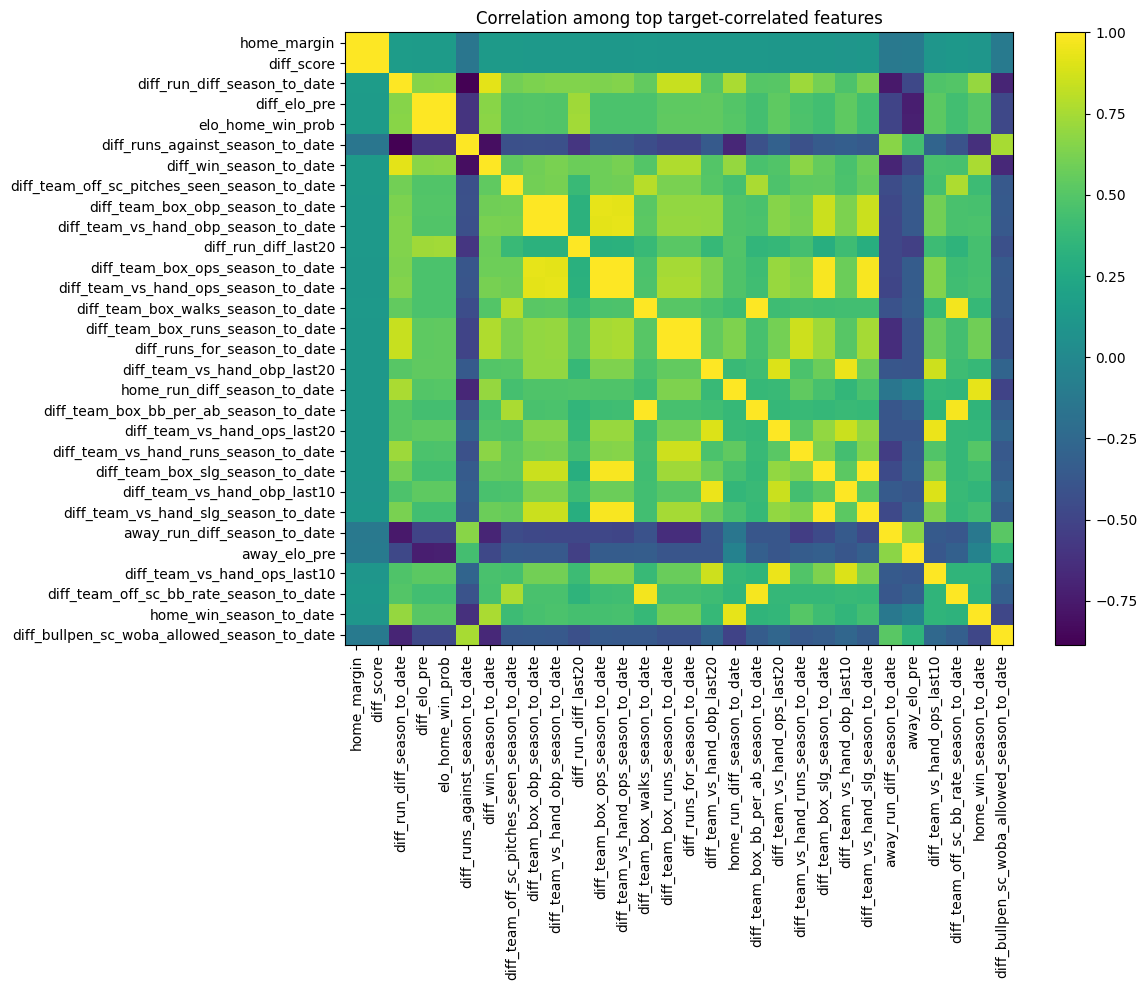

In [8]:
# Correlation heatmap for the top target-correlated features.
heatmap_features = corr_to_target.abs().head(30).index.tolist()

if heatmap_features:
    mat = numeric[heatmap_features].corr(numeric_only=True)
    plt.figure(figsize=(12, 10))
    plt.imshow(mat, aspect='auto')
    plt.xticks(range(len(heatmap_features)), heatmap_features, rotation=90)
    plt.yticks(range(len(heatmap_features)), heatmap_features)
    plt.colorbar()
    plt.title('Correlation among top target-correlated features')
    plt.tight_layout()
    plt.show()


## 5. Batted-ball comparison and interaction features

The upstream patches should create columns such as:

- `diff_team_off_sc_avg_batted_ball_ev_last20`
- `diff_team_off_sc_avg_batted_ball_distance_last20`
- `diff_team_vs_hand_sc_avg_batted_ball_ev_last20`
- `diff_team_vs_hand_sc_avg_batted_ball_distance_last20`

This section also creates a small set of baseball-logical interactions for testing. Do not blindly keep all interactions; promote them only when walk-forward log loss/Brier improve.


In [9]:
def add_interaction_terms(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    interaction_specs = [
        # Opponent contact quality × opposing starter contact allowed
        ('diff_team_off_sc_avg_batted_ball_ev_last20', 'diff_starter_statcast_sc_avg_batted_ball_ev_allowed_last10', 'int_team_ev_x_starter_ev_allowed'),
        ('diff_team_off_sc_avg_batted_ball_distance_last20', 'diff_starter_statcast_sc_avg_batted_ball_distance_allowed_last10', 'int_team_dist_x_starter_dist_allowed'),
        ('diff_team_off_sc_barrel_rate_last20', 'diff_starter_statcast_sc_barrel_rate_allowed_last10', 'int_team_barrel_x_starter_barrel_allowed'),
        ('diff_team_off_sc_hard_hit_rate_last20', 'diff_starter_statcast_sc_hard_hit_rate_allowed_last10', 'int_team_hardhit_x_starter_hardhit_allowed'),

        # Team offense vs hand × starter quality
        ('diff_team_vs_hand_sc_avg_batted_ball_ev_last20', 'diff_starter_statcast_sc_xwoba_allowed_contact_last10', 'int_vs_hand_ev_x_starter_xwoba_allowed'),
        ('diff_team_vs_hand_sc_barrel_rate_last20', 'diff_starter_statcast_sc_barrel_rate_allowed_last10', 'int_vs_hand_barrel_x_starter_barrel_allowed'),

        # Bullpen fatigue/quality × opponent offense quality
        ('diff_sc_bullpen_pitches_last3', 'diff_team_off_sc_hard_hit_rate_last20', 'int_bullpen_pitches_x_team_hardhit'),
        ('diff_bullpen_sc_xwoba_allowed_contact_last5', 'diff_team_off_sc_xwoba_contact_last20', 'int_bullpen_xwoba_allowed_x_team_xwoba'),
    ]

    created = []
    for a, b, name in interaction_specs:
        if a in out.columns and b in out.columns:
            out[name] = pd.to_numeric(out[a], errors='coerce') * pd.to_numeric(out[b], errors='coerce')
            created.append(name)

    print('Created interaction terms:', len(created))
    if created:
        display(pd.Series(created, name='interaction_features').to_frame())
    return out

completed_i = add_interaction_terms(completed)
features_i = add_interaction_terms(features)

interaction_cols = [c for c in completed_i.columns if c.startswith('int_') and pd.api.types.is_numeric_dtype(completed_i[c])]
feature_cols_with_interactions = [c for c in feature_cols_clean if c in completed_i.columns] + interaction_cols

print('Feature count with interactions:', len(feature_cols_with_interactions))


Created interaction terms: 4


,interaction_features
0,int_team_barrel_x_starter_barrel_allowed
1,int_team_hardhit_x_starter_hardhit_allowed
2,int_bullpen_pitches_x_team_hardhit
3,int_bullpen_xwoba_allowed_x_team_xwoba


Created interaction terms: 4


,interaction_features
0,int_team_barrel_x_starter_barrel_allowed
1,int_team_hardhit_x_starter_hardhit_allowed
2,int_bullpen_pitches_x_team_hardhit
3,int_bullpen_xwoba_allowed_x_team_xwoba


Feature count with interactions: 1757


## 5.5 Identifying Data Leakage Columns


In [17]:
import re
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

# Use the main dataframe name from the notebook
# Change `features` only if your dataframe has a different name.
completed_audit = features[features["target_home_win"].notna()].copy()
completed_audit["target_home_win"] = completed_audit["target_home_win"].astype(int)

y_audit = completed_audit["target_home_win"]

# Build feature_cols automatically
metadata_cols = {
    "target_home_win",
    "home_win",
    "game_pk",
    "run_id",
    "scored_at_utc",
    "official_date",
    "official_date_dt",
    "game_datetime_utc",
    "home_team_name",
    "away_team_name",
    "home_team_id",
    "away_team_id",
    "venue_name",
    "abstract_state",
    "detailed_state",
}

feature_cols = [
    c for c in completed_audit.columns
    if c not in metadata_cols
    and pd.api.types.is_numeric_dtype(completed_audit[c])
]

print("Audit feature count:", len(feature_cols))

hard_leak_patterns = [
    "target",
    "home_win",
    "away_win",
    "winner",
    "winning",
    "losing",
    "final",
    "result",
    "outcome",
    "actual",
    "margin",
    "total_runs",
    "home_score",
    "away_score",
    "home_runs",
    "away_runs",
    "run_diff",
    "post_",
]

hard_suspects = [
    c for c in feature_cols
    if any(p in c.lower() for p in hard_leak_patterns)
]

rolling_tokens = [
    "_last3",
    "_last5",
    "_last10",
    "_last20",
    "_season_to_date",
    "_pre",
]

same_game_box_suspects = []
for c in feature_cols:
    cl = c.lower()
    if cl.startswith(("home_team_box_", "away_team_box_", "diff_team_box_")):
        if not any(tok in cl for tok in rolling_tokens):
            same_game_box_suspects.append(c)

print("Hard leakage suspects:", len(hard_suspects))
display(pd.Series(hard_suspects, name="hard_suspects").head(150))

print("Potential same-game boxscore suspects:", len(same_game_box_suspects))
display(pd.Series(same_game_box_suspects, name="same_game_box_suspects").head(200))

Audit feature count: 1777
Hard leakage suspects: 74


0                                     home_score
1                                     away_score
2                                    home_margin
3                                     total_runs
4                        home_win_season_to_date
5                                 home_win_last3
6                                 home_win_last5
7                                home_win_last10
8                                home_win_last20
9                   home_runs_for_season_to_date
10                           home_runs_for_last3
11                           home_runs_for_last5
12                          home_runs_for_last10
13                          home_runs_for_last20
14              home_runs_against_season_to_date
15                       home_runs_against_last3
16                       home_runs_against_last5
17                      home_runs_against_last10
18                      home_runs_against_last20
19                  home_run_diff_season_to_date
20                  

Potential same-game boxscore suspects: 27


0       home_team_box_games_to_date
1                 home_team_box_xbh
2           home_team_box_bb_per_ab
3            home_team_box_k_per_ab
4           home_team_box_hr_per_ab
5         home_team_box_xbh_per_hit
6         home_team_box_sb_attempts
7     home_team_box_sb_success_rate
8         home_team_box_lob_per_run
9       away_team_box_games_to_date
10                away_team_box_xbh
11          away_team_box_bb_per_ab
12           away_team_box_k_per_ab
13          away_team_box_hr_per_ab
14        away_team_box_xbh_per_hit
15        away_team_box_sb_attempts
16    away_team_box_sb_success_rate
17        away_team_box_lob_per_run
18      diff_team_box_games_to_date
19                diff_team_box_xbh
20          diff_team_box_bb_per_ab
21           diff_team_box_k_per_ab
22          diff_team_box_hr_per_ab
23        diff_team_box_xbh_per_hit
24        diff_team_box_sb_attempts
25    diff_team_box_sb_success_rate
26        diff_team_box_lob_per_run
Name: same_game_box_suspects

In [18]:
single_feature_auc = []

for c in feature_cols:
    s = completed_audit[c]
    tmp = pd.DataFrame({"x": s, "y": y_audit}).dropna()

    if tmp["x"].nunique() < 2 or tmp["y"].nunique() < 2:
        continue

    try:
        auc = roc_auc_score(tmp["y"], tmp["x"])
        auc = max(auc, 1 - auc)
        single_feature_auc.append((c, auc, len(tmp), tmp["x"].nunique()))
    except Exception:
        pass

single_feature_auc = (
    pd.DataFrame(
        single_feature_auc,
        columns=["feature", "single_feature_auc", "n", "n_unique"]
    )
    .sort_values("single_feature_auc", ascending=False)
)

display(single_feature_auc.head(100))

,feature,single_feature_auc,n,n_unique
842,diff_score,1.000000,9074,41
4,home_margin,1.000000,9074,41
3,away_score,0.857070,9074,24
2,home_score,0.825496,9074,22
500,diff_run_diff_season_to_date,0.580787,9059,8950
485,diff_win_season_to_date,0.578713,9059,8713
495,diff_runs_against_season_to_date,0.575336,9059,8941
55,elo_home_win_prob,0.571196,9074,9040
54,diff_elo_pre,0.571196,9074,9040
850,diff_team_off_sc_pitches_seen_season_to_date,0.567073,9044,9001


## 6. Chronological split

Never use random splits for this problem. We use a chronological holdout so the model is tested on future-like data.


In [20]:
def chronological_split(df: pd.DataFrame, test_frac: float = 0.20):
    df = df.sort_values(["official_date", "game_datetime_utc", "game_pk"]).reset_index(drop=True)
    split_idx = int(len(df) * (1 - test_frac))
    return df.iloc[:split_idx].copy(), df.iloc[split_idx:].copy()


train_df, test_df = chronological_split(completed_i, test_frac=0.20)

print("Train rows:", len(train_df), train_df["official_date"].min(), "to", train_df["official_date"].max())
print("Test rows:", len(test_df), test_df["official_date"].min(), "to", test_df["official_date"].max())

TARGET_COL = "target_home_win"

y_train = train_df[TARGET_COL].astype(int)
y_test = test_df[TARGET_COL].astype(int)

baseline_train_rate = y_train.mean()
baseline_probs = np.repeat(baseline_train_rate, len(y_test))

baseline_metrics = {
    'model_name': 'constant_train_home_rate',
    'n_test': len(y_test),
    'avg_pred': float(baseline_probs.mean()),
    'actual_rate': float(y_test.mean()),
    'log_loss': float(log_loss(y_test, baseline_probs)),
    'brier': float(brier_score_loss(y_test, baseline_probs)),
    'roc_auc': 0.5,
    'accuracy_50pct': float(accuracy_score(y_test, baseline_probs >= 0.5)),
}

display(pd.DataFrame([baseline_metrics]))


Train rows: 7259 2022-08-02 00:00:00 to 2025-07-22 00:00:00
Test rows: 1815 2025-07-22 00:00:00 to 2026-06-01 00:00:00


,model_name,n_test,avg_pred,actual_rate,log_loss,brier,roc_auc,accuracy_50pct
0,constant_train_home_rate,1815,0.530789,0.530579,0.691276,0.249065,0.5,0.530579


## 7. Model feature sets

The goal is to identify whether batted-ball features and interaction terms actually improve the proper scoring metrics.


In [11]:
def cols_matching(cols, include_any=(), exclude_any=()):
    out = []
    for c in cols:
        low = c.lower()
        if include_any and not any(x in low for x in include_any):
            continue
        if exclude_any and any(x in low for x in exclude_any):
            continue
        out.append(c)
    return out

# Pure baseball features exclude market columns by default.
pure_base_cols = [c for c in feature_cols_clean if c not in market_cols]
pure_base_cols_i = [c for c in feature_cols_with_interactions if c not in market_cols]

feature_sets = {
    'baseline_no_market': pure_base_cols,
    'batted_ball_only': cols_matching(pure_base_cols_i, include_any=('batted_ball', 'avg_ev', 'max_ev', 'p90_batted', 'distance', 'hard_hit', 'barrel')),
    'statcast_only': [c for c in pure_base_cols_i if c in statcast_cols or c in interaction_cols],
    'starter_statcast': cols_matching(pure_base_cols_i, include_any=('starter_statcast',)),
    'team_statcast': cols_matching(pure_base_cols_i, include_any=('team_off_sc', 'team_vs_hand_sc', 'batted_ball')),
    'enhanced_with_interactions': pure_base_cols_i,
}

# Optional market-aware set once you have adequate historical odds coverage.
market_available = [c for c in market_cols if completed_i[c].notna().mean() > 0.50] if market_cols else []
if market_available:
    feature_sets['market_aware'] = pure_base_cols_i + market_available

for name, cols in feature_sets.items():
    cols = [c for c in cols if c in completed_i.columns and pd.api.types.is_numeric_dtype(completed_i[c])]
    feature_sets[name] = cols
    print(name, len(cols))


baseline_no_market 1753
batted_ball_only 214
statcast_only 1096
starter_statcast 390
team_statcast 432
enhanced_with_interactions 1757


## 8. Define models

This includes a logit benchmark and several tree/boosting models. XGBoost and LightGBM are optional.


In [12]:
def make_pipeline(model, scale=False):
    steps = [('imputer', SimpleImputer(strategy='median', add_indicator=True))]
    if scale:
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', model))
    return Pipeline(steps)

models = {
    'logit_l2': make_pipeline(LogisticRegression(max_iter=5000, C=0.5, solver='lbfgs'), scale=True),
    'random_forest': make_pipeline(RandomForestClassifier(n_estimators=500, min_samples_leaf=25, max_features='sqrt', random_state=42, n_jobs=-1)),
    'extra_trees': make_pipeline(ExtraTreesClassifier(n_estimators=500, min_samples_leaf=25, max_features='sqrt', random_state=42, n_jobs=-1)),
    'hist_gbdt': make_pipeline(HistGradientBoostingClassifier(max_iter=300, learning_rate=0.03, max_leaf_nodes=15, l2_regularization=0.1, random_state=42)),
}

try:
    from xgboost import XGBClassifier
    models['xgboost'] = make_pipeline(XGBClassifier(
        n_estimators=300,
        max_depth=2,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        min_child_weight=10,
        reg_alpha=0.0,
        reg_lambda=2.0,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
    ))
except Exception as e:
    print('Skipping XGBoost:', repr(e))

try:
    from lightgbm import LGBMClassifier
    models['lightgbm'] = make_pipeline(LGBMClassifier(
        n_estimators=400,
        max_depth=3,
        learning_rate=0.03,
        num_leaves=15,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.0,
        reg_lambda=2.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ))
except Exception as e:
    print('Skipping LightGBM:', repr(e))

print(models.keys())


dict_keys(['logit_l2', 'random_forest', 'extra_trees', 'hist_gbdt', 'xgboost', 'lightgbm'])


## 9. Fit/evaluate model × feature set grid

This keeps runtime reasonable by using a single chronological holdout. After identifying promising configurations, you can add walk-forward folds.


In [13]:
def evaluate_model(name, model, cols):
    X_train = train_df[cols].copy()
    X_test = test_df[cols].copy()

    fitted = clone(model)
    fitted.fit(X_train, y_train)

    if hasattr(fitted, 'predict_proba'):
        p = fitted.predict_proba(X_test)[:, 1]
    else:
        # Very rare fallback.
        raw = fitted.decision_function(X_test)
        p = 1 / (1 + np.exp(-raw))

    p = np.clip(p, 1e-6, 1 - 1e-6)
    pred = (p >= 0.5).astype(int)

    metrics = {
        'model_name': name,
        'feature_count': len(cols),
        'n_test': len(y_test),
        'avg_pred': float(np.mean(p)),
        'actual_rate': float(y_test.mean()),
        'log_loss': float(log_loss(y_test, p)),
        'brier': float(brier_score_loss(y_test, p)),
        'roc_auc': float(roc_auc_score(y_test, p)),
        'accuracy_50pct': float(accuracy_score(y_test, pred)),
    }
    return fitted, p, metrics

results = []
fitted_models = {}
preds_by_name = {}

for fs_name, cols in feature_sets.items():
    if len(cols) < 3:
        print('Skipping tiny feature set:', fs_name, len(cols))
        continue
    for model_name, model in models.items():
        full_name = f'{fs_name}__{model_name}'
        try:
            fitted, p, metrics = evaluate_model(full_name, model, cols)
            results.append(metrics)
            fitted_models[full_name] = (fitted, cols)
            preds_by_name[full_name] = p
            print(full_name, 'log_loss=', round(metrics['log_loss'], 4), 'brier=', round(metrics['brier'], 4), 'auc=', round(metrics['roc_auc'], 4))
        except Exception as e:
            print('FAILED', full_name, repr(e))

results_df = pd.DataFrame(results).sort_values(['log_loss', 'brier']).reset_index(drop=True)
display(results_df)


baseline_no_market__logit_l2 log_loss= 0.0201 brier= 0.0029 auc= 0.9998
baseline_no_market__random_forest log_loss= 0.437 brier= 0.1266 auc= 1.0
baseline_no_market__extra_trees log_loss= 0.6363 brier= 0.2219 auc= 0.8275
baseline_no_market__hist_gbdt log_loss= 0.0001 brier= 0.0 auc= 1.0
baseline_no_market__xgboost log_loss= 0.003 brier= 0.0 auc= 1.0
baseline_no_market__lightgbm log_loss= 0.0001 brier= 0.0 auc= 1.0
batted_ball_only__logit_l2 log_loss= 0.7004 brier= 0.253 auc= 0.516
batted_ball_only__random_forest log_loss= 0.6881 brier= 0.2475 auc= 0.544
batted_ball_only__extra_trees log_loss= 0.6893 brier= 0.2481 auc= 0.5367
batted_ball_only__hist_gbdt log_loss= 0.7013 brier= 0.2539 auc= 0.5096
batted_ball_only__xgboost log_loss= 0.6916 brier= 0.2492 auc= 0.5303
batted_ball_only__lightgbm log_loss= 0.6966 brier= 0.2516 auc= 0.5185
statcast_only__logit_l2 log_loss= 0.7329 brier= 0.265 auc= 0.5564
statcast_only__random_forest log_loss= 0.6845 brier= 0.2457 auc= 0.5607
statcast_only__extra

,model_name,feature_count,n_test,avg_pred,actual_rate,log_loss,brier,roc_auc,accuracy_50pct
0,baseline_no_market__hist_gbdt,1753,1815,0.530578,0.530579,0.000084,7.095310e-09,1.000000,1.000000
1,enhanced_with_interactions__hist_gbdt,1757,1815,0.530578,0.530579,0.000084,7.095310e-09,1.000000,1.000000
2,enhanced_with_interactions__lightgbm,1757,1815,0.530578,0.530579,0.000146,2.150349e-08,1.000000,1.000000
3,baseline_no_market__lightgbm,1753,1815,0.530578,0.530579,0.000147,2.175191e-08,1.000000,1.000000
4,enhanced_with_interactions__xgboost,1757,1815,0.530578,0.530579,0.002991,8.955106e-06,1.000000,1.000000
5,baseline_no_market__xgboost,1753,1815,0.530578,0.530579,0.002992,8.957695e-06,1.000000,1.000000
6,baseline_no_market__logit_l2,1753,1815,0.534069,0.530579,0.020141,2.868252e-03,0.999805,0.998898
7,enhanced_with_interactions__logit_l2,1757,1815,0.533812,0.530579,0.020704,2.944068e-03,0.999745,0.998898
8,baseline_no_market__random_forest,1753,1815,0.534153,0.530579,0.436983,1.265724e-01,0.999950,0.995592
9,enhanced_with_interactions__random_forest,1757,1815,0.534462,0.530579,0.447989,1.316208e-01,0.999940,0.994490


## 10. Champion diagnostics


Best model: baseline_no_market__hist_gbdt
Feature count: 1753
{'model_name': 'baseline_no_market__hist_gbdt', 'feature_count': 1753, 'n_test': 1815, 'avg_pred': 0.53057848948514, 'actual_rate': 0.5305785123966942, 'log_loss': 8.408093520237522e-05, 'brier': 7.095309716605144e-09, 'roc_auc': 1.0, 'accuracy_50pct': 1.0}
Classification report at 50% threshold:
              precision    recall  f1-score   support

           0      1.000     1.000     1.000       852
           1      1.000     1.000     1.000       963

    accuracy                          1.000      1815
   macro avg      1.000     1.000     1.000      1815
weighted avg      1.000     1.000     1.000      1815

Confusion matrix:


,pred_away,pred_home
actual_away,852,0
actual_home,0,963


,games,avg_pred_prob,actual_home_win_rate,calibration_error
bucket,,,,
"(-0.001, 0.35]",852,0.000090,0.0,-0.000090
"(0.35, 0.4]",0,NaN,NaN,NaN
"(0.4, 0.45]",0,NaN,NaN,NaN
"(0.45, 0.5]",0,NaN,NaN,NaN
"(0.5, 0.55]",0,NaN,NaN,NaN
"(0.55, 0.6]",0,NaN,NaN,NaN
"(0.6, 0.65]",0,NaN,NaN,NaN
"(0.65, 0.7]",0,NaN,NaN,NaN
"(0.7, 1.0]",963,0.999921,1.0,0.000079


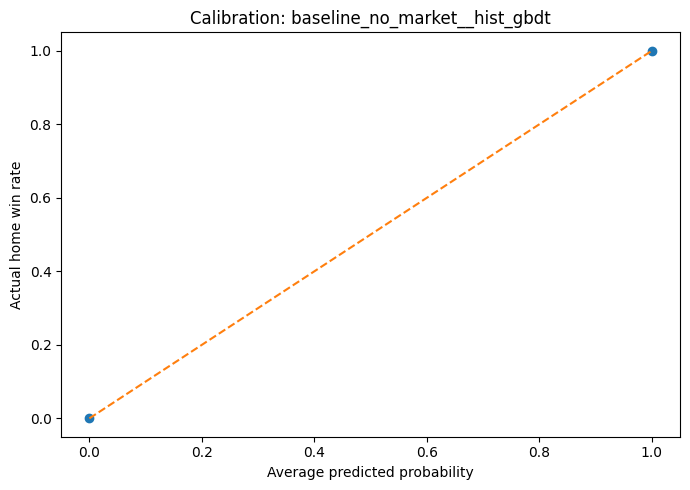

In [14]:
best_name = results_df.iloc[0]['model_name']
best_model, best_cols = fitted_models[best_name]
best_p = preds_by_name[best_name]

print('Best model:', best_name)
print('Feature count:', len(best_cols))
print(results_df.iloc[0].to_dict())

print('Classification report at 50% threshold:')
print(classification_report(y_test, (best_p >= 0.5).astype(int), digits=3))
print('Confusion matrix:')
display(pd.DataFrame(confusion_matrix(y_test, (best_p >= 0.5).astype(int)), index=['actual_away','actual_home'], columns=['pred_away','pred_home']))

calib = pd.DataFrame({'p': best_p, 'y': y_test.values})
calib['bucket'] = pd.cut(calib['p'], bins=[0, .35, .40, .45, .50, .55, .60, .65, .70, 1.0], include_lowest=True)
calib_table = calib.groupby('bucket', observed=False).agg(
    games=('y','size'),
    avg_pred_prob=('p','mean'),
    actual_home_win_rate=('y','mean'),
)
calib_table['calibration_error'] = calib_table['actual_home_win_rate'] - calib_table['avg_pred_prob']
display(calib_table)

plt.figure(figsize=(7,5))
plt.plot(calib_table['avg_pred_prob'], calib_table['actual_home_win_rate'], marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('Average predicted probability')
plt.ylabel('Actual home win rate')
plt.title(f'Calibration: {best_name}')
plt.tight_layout()
plt.show()


## 11. Permutation importance

This is slower, so it uses the holdout set and the current champion only.


In [ ]:
RUN_PERMUTATION_IMPORTANCE = True

if RUN_PERMUTATION_IMPORTANCE:
    X_test_best = test_df[best_cols].copy()
    perm = permutation_importance(
        best_model,
        X_test_best,
        y_test,
        scoring='neg_log_loss',
        n_repeats=5,
        random_state=42,
        n_jobs=-1,
    )
    imp = pd.DataFrame({
        'feature': best_cols,
        'importance_mean': perm.importances_mean,
        'importance_std': perm.importances_std,
    }).sort_values('importance_mean', ascending=False)
    display(imp.head(80))
else:
    print('Permutation importance skipped.')


## 12. Optional champion export

Set `APPROVE_EXPORT = True` only after you are comfortable with the diagnostics. The bundle includes the model and exact feature columns, which keeps production scoring consistent.


In [ ]:
APPROVE_EXPORT = False

if APPROVE_EXPORT:
    import joblib
    bundle = {
        'model': best_model,
        'feature_cols': best_cols,
        'model_name': best_name,
        'metrics': results_df.iloc[0].to_dict(),
        'target_col': TARGET_COL,
        'created_from_features_path': str(FEATURES_PATH),
    }
    model_path = MODEL_DIR / 'mlb_moneyline_champion.joblib'
    metadata_path = MODEL_DIR / 'mlb_moneyline_champion_metadata.json'
    joblib.dump(bundle, model_path)
    metadata_path.write_text(json.dumps({k: v for k, v in bundle.items() if k != 'model'}, default=str, indent=2))
    print('Saved:', model_path)
    print('Saved:', metadata_path)
else:
    print('APPROVE_EXPORT is False; not exporting.')
